# Fundamentals OpenCV

- basic image processing
- noise and denoise
- matplotlib

1. Read an image, convert to rgb and then to HSV and the show the images.

In [1]:
import cv2

img = cv2.imread('scene.png')
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

cv2.imshow('RGB Image', rgb_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.imshow('HSV Image', hsv_img)
cv2.waitKey(0)
cv2.destroyAllWindows()


2. Change the format of an image from PNG to JPG in your system using OpenCV.

In [2]:
png_to_jpg = cv2.imwrite('scene-converted.jpg', img)

3. Read an image.

- Display the image using OpenCV and Matplotlib.
- What differences do you observe?<br>

    + Passing an unconverted OpenCV image directly into plt.imshow(img) causes color distortion. Red objects will appear blue, and blue objects will look red. This happens because Matplotlib reads the first data channel as Red(RGB), but OpenCV populated it with Blue(BGR).

    + OpenCV creates a separate desktop window rendered by MacOS GUI. Matplotlib renders the image inline within Jupyter notebook (like Jupyter).

    + Matplotlib automatically wraps the image with labeled horizontal and vertical pixel coordinate axes. OpenCV displays only the raw image matrix data.
    
- Save the image using both OpenCV and Matplotlib.

In [146]:
# Showing image using OpenCV
cv2.imshow('OpenCV Image Display', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Saving image using OpenCV
cv2.imwrite('saved_via_opencv.jpg', img)


True

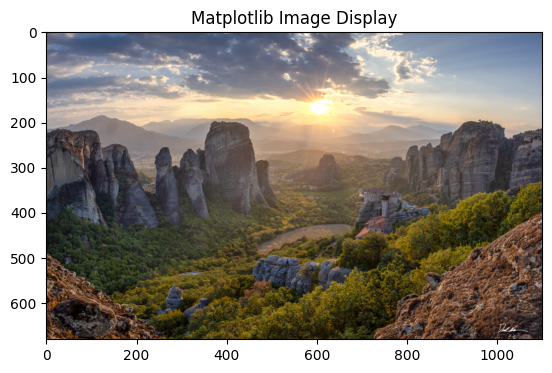

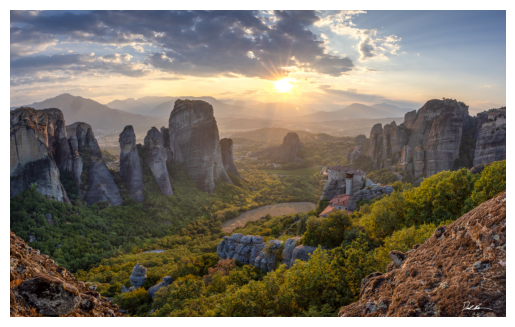

In [14]:
import matplotlib.pyplot as plt

# Showing the image using Matplotlib
plt.imshow(rgb_img)
plt.title('Matplotlib Image Display')
plt.show()

# Saving the image using Matplotlib
plt.imshow(rgb_img)
plt.axis('off')
plt.savefig('saved_via_matplotlib.png', bbox_inches='tight', pad_inches=0)


4. 
- Add padding to all four sides of the image using a border of 50 pixels.
Try at least three border types. What visual differences do you see?

    + Solid Border: cv2.BORDER_CONSTANT creates a clean, uniform frame around the image. The padding is entirely filled with one single color of our choice. The edge of the original image remains sharply defined.

    + Stretched Border: cv2.BORDER_REPLICATE grabs the very last row or column of pixels on the image edge and repeats them outwards for 50 pixels. Visually, it looks like the edges of our image have been dragged straight out creating thick vertical and horizontal stripes.
    
    + Mirrored Border: cv2.BORDER_REFLECT mirrors the image elements directly along the boundary line. It's basically upside-down reflection of that image for that many pixels (50 in this case). 

- How can you change the color of padding
    + To change the color of the padding we must use cv2.BORDER_CONSTANT as it is the only border type that accepts the optional value parameter. We can pass our desired color array (value=[0, 255, 0]) into this parameter. However, we must ensure the color channels match our current image array layout (BGR or RGB).

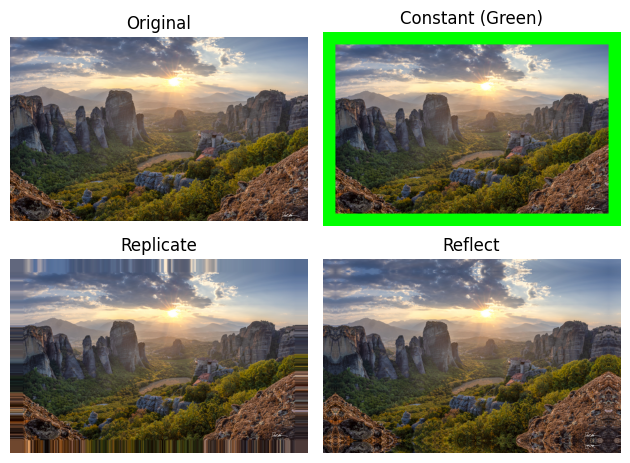

In [147]:
# 1. Constant Border (Solid Color)
border_constant = cv2.copyMakeBorder(rgb_img, 50, 50, 50, 50,
                                     cv2.BORDER_CONSTANT, value=[0, 255, 0]) 

# 2. Replicate Border (Stretch Edge Pixels)
border_replicate = cv2.copyMakeBorder(rgb_img, 50, 50, 50, 50,
                                      cv2.BORDER_REPLICATE)

# 3. Reflect Border (Mirror Image at Edges)
border_reflect = cv2.copyMakeBorder(rgb_img, 50, 50, 50, 50, 
                                     cv2.BORDER_REFLECT)

# Display the results using Matplotlib
titles = ['Original', 'Constant (Green)', 'Replicate', 'Reflect']
images = [rgb_img, border_constant, border_replicate, border_reflect]

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


5. You are building a simple image processing pipeline. Your goal is to:

- Keep the original image unchanged.
- Create a version with a red square in the top-left corner.

What would you do?
- I would afely duplicate the original image using .copy() so that the original data remains completely untouched. Then use cv2.circle() to draw a red circle on the duplicated image, placing the center at pixel coordinates (100, 100) with a radius of 100 pixels, a line thickness of 8 pixels, and a standard RGB color tuple of (255, 0, 0) for pure red. Finally, use Matplotlib to display both images side-by-side confirming that the circle overlay was successfully applied to the new image while the original image stays perfectly clean.

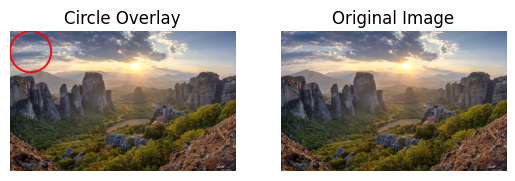

In [148]:
circle_image = rgb_img.copy()
cv2.circle(circle_image, (100, 100), 100, (255, 0, 0), thickness=8) 

# Display the image with the circle overlay
plt.subplot(1, 2, 1)
plt.imshow(circle_image)
plt.title('Circle Overlay')
plt.axis('off')

# Display the original image
plt.subplot(1, 2, 2)
plt.imshow(rgb_img)
plt.title('Original Image')
plt.axis('off')
plt.show()

6. Plot the function y = x^2+6 using Matplotlib.

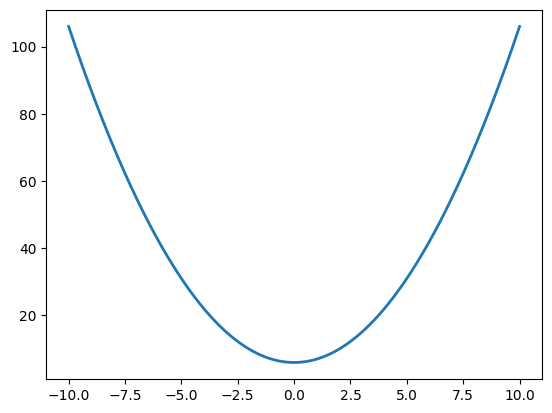

In [149]:
import numpy as np

x = np.linspace(-10, 10, 400)
y = x**2 + 6
plt.plot(x, y, label=r'$y = x^2 + 6$', linewidth=2)

plt.show()


7. Plot sin(x) and cos(x) on the same figure. Add grid, labels, title, and legend.

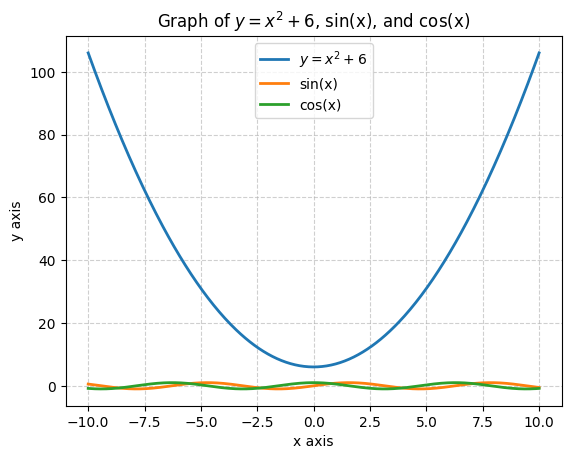

In [150]:
plt.plot(x, x**2 + 6, label=r'$y = x^2 + 6$', linewidth=2)
plt.plot(x, np.sin(x), label='sin(x)', linewidth=2)
plt.plot(x, np.cos(x), label='cos(x)', linewidth=2)

plt.title(r'Graph of $y = x^2 + 6$, sin(x), and cos(x)')
plt.xlabel('x axis')
plt.ylabel('y axis')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

8. Read an image and display it alongside its grayscaled version using matplotlib.

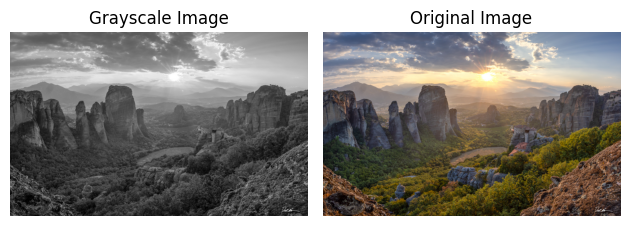

In [153]:
grey_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2GRAY)

plt.subplot(1, 2, 1)
plt.imshow(grey_img, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_img)
plt.title('Original Image')
plt.axis('off')

plt.tight_layout()
plt.show()


9. Having an image, create a 1x3 subplot that shows:

- Original RGB image
- Red channel
- HSV version
- Adjust the figure size for better visualization.

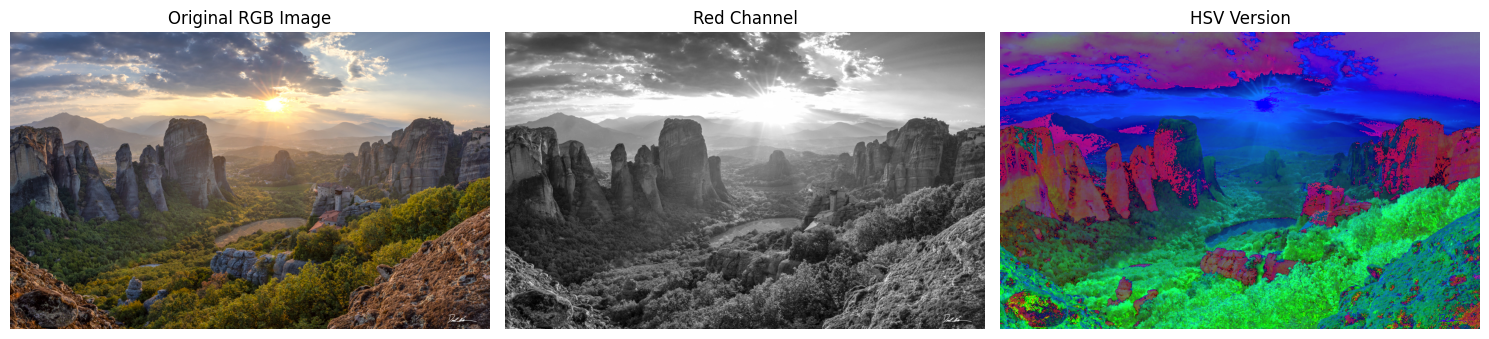

In [154]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(rgb_img)
plt.title('Original RGB Image')
plt.axis('off') 

plt.subplot(1, 3, 2)
plt.imshow(rgb_img[:, :, 0], cmap='gray') 
plt.title('Red Channel')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hsv_img)
plt.title('HSV Version')
plt.axis('off')


plt.tight_layout()
plt.show()


10. Search about Histograms and explain them. Plot a sample histogram below.
    + A Histogram is a specialized statistical graph used to show how numerical data is distributed across different continuous intervals (called bins). Unlike a bar chart which compares discrete categories (like mango vs orange) a histogram groups continuous numbers (like age/height/weight) to reveal patterns like skewness, variations, or peak frequencies.

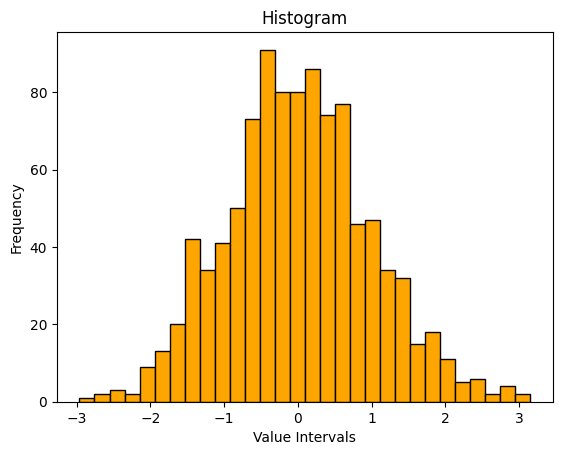

In [155]:
data = np.random.randn(1000) # Generate 1000 random data points following a normal distribution

plt.hist(data, bins=30, color='orange', edgecolor='black')

plt.title('Histogram')
plt.xlabel('Value Intervals')
plt.ylabel('Frequency')

plt.show()

11. Create the following plots.

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20250418110446696566/histogram.png" alt="plot1" width="400"/>
<img src="https://texasgateway.org/sites/default/files/h5p/content/5891/images/solutionImage-5776c0e1abe81.png" alt="plot3" width="400"/>


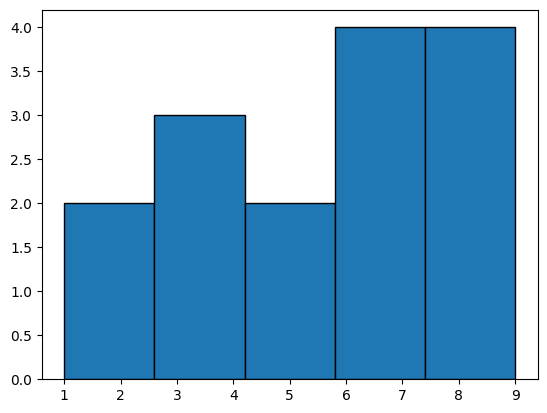

In [141]:
data = [
    1.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 6.5, 7.0, 7.2, 7.5, 8.0, 8.5, 9.0              
]

plt.hist(data, bins=5, range=(1, 9), edgecolor='black')
plt.show()


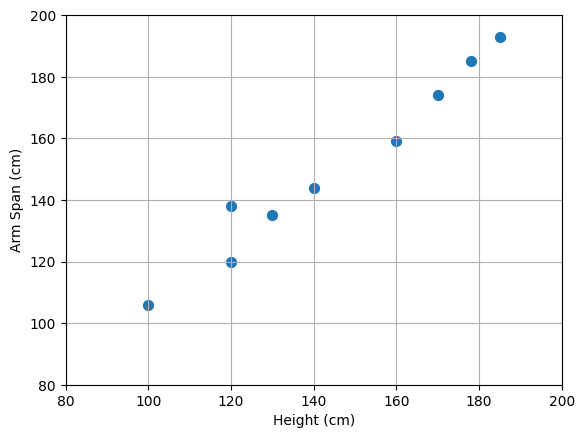

: 

In [ ]:
height = [100, 120, 120, 130, 140, 160, 170, 178, 185]
arm_span = [106, 120, 138, 135, 144, 159, 174, 185, 193]

plt.scatter(height, arm_span, s=50)

plt.xlabel('Height (cm)')
plt.ylabel('Arm Span (cm)')
plt.xlim(80, 200)
plt.ylim(80, 200)

plt.grid(True, which='both', linestyle='-')
plt.show()

# Well Done!